# Loading packages

Installing necessary packages

In [1]:
# %pip install sodapy
# %pip install geopandas
# %pip install ipywidgets
# %pip install tqdm

Loading the necessary packages

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from sodapy import Socrata
import requests

import tqdm
import json
import os
import shapely
import folium
import time

env = os.environ

---
# Getting the data

## Setup

In [3]:
# Settings
app_token = env.get("APP_TOKEN")
client = Socrata("data.ny.gov", app_token = app_token, timeout=240)

### Defining function to get data via API

In [4]:
def get_all_MTA_data(DATASET_ID, query_template, limit, filename = None):
    """
    Fetch all data from the Socrata API using pagination.
    
    Parameters:
    - DATASET_ID: The dataset ID on the Socrata platform.
    - query_template: The SQL-like query string with placeholders for LIMIT and OFFSET.
    - limit: The number of rows to fetch per page.
    - filename (optional): If provided, the final DataFrame will be saved to a CSV file.

    Returns:
    - A Pandas DataFrame containing all the fetched data.
    """

    all_data = []
    offset = 0

    while True:
        query = query_template.format(limit=limit, offset=offset)
        result = client.get(DATASET_ID, query=query)
        data = pd.DataFrame.from_records(result)

        if data.empty:
            break
        all_data.append(data)
        offset += limit
        print(f"Fetched {len(data)} records, total offset now {offset}")

        if limit >= 100000:
            time.sleep(1)

    final_df = pd.concat(all_data, ignore_index=True)

    if filename:
        final_df.to_csv(filename, index=False)
    
    return final_df

## Getting `Bus segment speed data`

Files can be found here:

> **Note**: I am only looking at Manhattan data for now

https://data.ny.gov/Transportation/MTA-Bus-Route-Segment-Speeds-Beginning-2025/kufs-yh3x/about_data
https://data.ny.gov/Transportation/MTA-Bus-Route-Segment-Speeds-2023-2024/58t6-89vi/about_data

### Using API to request bus segment speed data

In [5]:
query_25 = """SELECT *
WHERE Borough = 'Manhattan'
LIMIT {limit} OFFSET {offset}
"""
segment_base_name_25 = "MTA_Bus_Route_Segment_Speeds_Beginning_2025"
segment_existing_file_25 = next((f for f in os.listdir("Data") if f.startswith(segment_base_name_25)), None)

if segment_existing_file_25:
    segment_filename_25 = os.path.join("Data", segment_existing_file_25)
    print(f"Found existing file {segment_filename_25}, skipping API pull.")
else:
    segment_filename_25 = f"Data/{segment_base_name_25}_{datetime.now().strftime('%Y%m%d')}.csv"
    bus_speed_seg_2025 = get_all_MTA_data("kufs-yh3x", query_25, 100000, segment_filename_25)

Found existing file Data/MTA_Bus_Route_Segment_Speeds_Beginning_2025_20251105.csv, skipping API pull.


In [6]:
query_23_24 = """SELECT *
WHERE Borough = 'Manhattan'
LIMIT {limit} OFFSET {offset}
"""
segment_base_name_23_24 = "MTA_Bus_Route_Segment_Speeds_2023_2024"
segment_existing_file_23_24 = next((f for f in os.listdir("Data") if f.startswith(segment_base_name_23_24)), None)

if segment_existing_file_23_24:
    segment_filename_23_24 = os.path.join("Data", segment_existing_file_23_24)
    print(f"Found existing file {segment_filename_23_24}, skipping API pull.")
else:
    segment_filename_23_24 = f"Data/{segment_base_name_23_24}_{datetime.now().strftime('%Y%m%d')}.csv"
    bus_speed_seg_2023_2024 = get_all_MTA_data("58t6-89vi", query_23_24, 100000, segment_filename_23_24)

Found existing file Data/MTA_Bus_Route_Segment_Speeds_2023_2024.csv, skipping API pull.


### Loading the data from files

In [7]:
# loading 2025 data from file
bus_speed_seg_2025 = pd.read_csv(segment_filename_25)
# loading 2023-2024 data from file
bus_speed_seg_2023_2024 = pd.read_csv(segment_filename_23_24)

## Getting `Stop Data`

Got stop data using this github project:



In [8]:
stop_data = pd.read_csv("Data/manhattan_stops_flat.csv")

## Getting `Bus speed data`

Loaded data from website. Files can be found here:

https://data.ny.gov/Transportation/MTA-Bus-Speeds-Beginning-2025/4u4b-jge6/about_data  
https://data.ny.gov/Transportation/MTA-Bus-Speeds-2020-2024/6ksi-7cxr/about_data

### Using API to request bus speed data

In [9]:
query_25 = """SELECT *
WHERE Borough = 'Manhattan'
LIMIT {limit} OFFSET {offset}
"""
bus_speed_base_name_25 = "MTA_Bus_Speeds_Beginning_2025"
bus_speed_existing_25 = next((f for f in os.listdir("Data") if f.startswith(bus_speed_base_name_25)), None)

if bus_speed_existing_25:
    bus_speed_filename_25 = os.path.join("Data", bus_speed_existing_25)
    print(f"Found existing file {bus_speed_filename_25}, skipping API pull.")
else:
    bus_speed_filename_25 = f"Data/{bus_speed_base_name_25}_{datetime.now().strftime('%Y%m%d')}.csv"
    bus_speed_2025 = get_all_MTA_data("4u4b-jge6", query_25, 1000, bus_speed_filename_25)

Found existing file Data/MTA_Bus_Speeds_Beginning_2025_20251105.csv, skipping API pull.


In [10]:
query_23_24 = """SELECT *
WHERE Borough = 'Manhattan'
  AND month BETWEEN '2023-01-01T00:00:00' AND '2024-12-31T23:59:59'
LIMIT {limit} OFFSET {offset}
"""
bus_speed_base_name_23_24 = "MTA_Bus_Speeds_2023_2024"
bus_speed_existing_23_24 = next((f for f in os.listdir("Data") if f.startswith(bus_speed_base_name_23_24)), None)

if bus_speed_existing_23_24:
    bus_speed_filename_23_24 = os.path.join("Data", bus_speed_existing_23_24)
    print(f"Found existing file {bus_speed_filename_23_24}, skipping API pull.")
else:
    bus_speed_filename_23_24 = f"Data/{bus_speed_base_name_23_24}_{datetime.now().strftime('%Y%m%d')}.csv"
    bus_speed_2023_2024 = get_all_MTA_data("6ksi-7cxr", query_23_24, 1000, bus_speed_filename_23_24)

Found existing file Data/MTA_Bus_Speeds_2023_2024_20251105.csv, skipping API pull.


### Loading data from files

In [11]:
# loading 2025 data from file
bus_speed_2025 = pd.read_csv(bus_speed_filename_25)
# loading 2023-2024 data from file
bus_speed_2023_2024 = pd.read_csv(bus_speed_filename_23_24)

## Getting `Hourly ridership data`

Loaded files from website. Files can be found here:

https://data.ny.gov/Transportation/MTA-Bus-Hourly-Ridership-Beginning-2025/gxb3-akrn/about_data 
https://data.ny.gov/Transportation/MTA-Bus-Hourly-Ridership-2020-2024/kv7t-n8in/about_data



### Getting the data from the API

In [12]:
query_25 = """SELECT transit_timestamp, bus_route, sum(ridership) as total_ridership
WHERE caseless_starts_with(bus_route, 'M')
GROUP BY transit_timestamp, bus_route
LIMIT {limit} OFFSET {offset}
"""
ridership_base_name_25 = "MTA_Bus_Hourly_Ridership_Beginning_2025"
ridership_existing_25 = next((f for f in os.listdir("Data") if f.startswith(ridership_base_name_25)), None)

if ridership_existing_25:
    ridership_filename_25 = os.path.join("Data", ridership_existing_25)
    print(f"Found existing file {ridership_filename_25}, skipping API pull.")
else:
    ridership_filename_25 = f"Data/{ridership_base_name_25}_{datetime.now().strftime('%Y%m%d')}.csv"
    hourly_ridership_2025 = get_all_MTA_data("gxb3-akrn", query_25, 100000, ridership_filename_25)

Found existing file Data/MTA_Bus_Hourly_Ridership_Beginning_2025_20251105.csv, skipping API pull.


In [13]:
query_23_24 = """SELECT transit_timestamp, bus_route, sum(ridership) as total_ridership
WHERE caseless_starts_with(bus_route, 'M')
  AND transit_timestamp BETWEEN '2023-01-01T00:00:00' AND '2024-12-31T23:59:59'
GROUP BY transit_timestamp, bus_route
LIMIT {limit} OFFSET {offset}
"""
ridership_base_name_23_24 = "MTA_Bus_Hourly_Ridership_2023_2024"
ridership_existing_23_24 = next((f for f in os.listdir("Data") if f.startswith(ridership_base_name_23_24)), None)

if ridership_existing_23_24:
    ridership_filename_23_24 = os.path.join("Data", ridership_existing_23_24)
    print(f"Found existing file {ridership_filename_23_24}, skipping API pull.")
else:
    ridership_filename_23_24 = f"Data/{ridership_base_name_23_24}_{datetime.now().strftime('%Y%m%d')}.csv"
    hourly_ridership_2023_2024 = get_all_MTA_data("kv7t-n8in", query_23_24, 100000, ridership_filename_23_24)

Found existing file Data/MTA_Bus_Hourly_Ridership_2023_2024_20251105.csv, skipping API pull.


### Loading data from files

In [14]:
# loading 2025 data from file
hourly_ridership_2025 = pd.read_csv(ridership_filename_25)
# loading 2023-2024 data from file
hourly_ridership_2023_2024 = pd.read_csv(ridership_filename_23_24)

## Getting `Hourly Tunnel and Bridges Crossings`

I got the data from here:

https://data.ny.gov/Transportation/MTA-Bridges-and-Tunnels-Hourly-Crossings-Beginning/ebfx-2m7v/about_data

### Using API to request crossings data

In [15]:
query_23_25 = """SELECT date, hour, facility, direction, sum(traffic_count) as total_count
WHERE date BETWEEN '2023-01-01T00:00:00' AND '2025-12-31T23:59:59'
GROUP BY date, hour, facility, direction
LIMIT {limit} OFFSET {offset}
"""
crossings_base_name = "MTA_Bus_Hourly_Crossings_2023_2025"
crossings_existing = next((f for f in os.listdir("Data") if f.startswith(crossings_base_name)), None)

if crossings_existing:
    crossings_filename_23_25 = os.path.join("Data", crossings_existing)
    print(f"Found existing file {crossings_filename_23_25}, skipping API pull.")
else:
    crossings_filename_23_25 = f"Data/{crossings_base_name}_{datetime.now().strftime('%Y%m%d')}.csv"
    hourly_crossings_2023_2025 = get_all_MTA_data("ebfx-2m7v", query_23_25, 100000, crossings_filename_23_25)

Found existing file Data/MTA_Bus_Hourly_Crossings_2023_2025_20251105.csv, skipping API pull.


### Loading the data from files

In [16]:
# loading 2023-2025 data from file
hourly_crossings_2023_2025 = pd.read_csv(crossings_filename_23_25)

## Getting `Congestion Relief Zone Vehicle Entries`

I got the data from here:

https://data.ny.gov/Transportation/MTA-Congestion-Relief-Zone-Vehicle-Entries-Beginni/t6yz-b64h/about_data

In [17]:
query_25 = """SELECT *
LIMIT {limit} OFFSET {offset}
"""
crz_base_name = "MTA_CRZ_Hourly_Entries_2023_2025"
crz_existing = next((f for f in os.listdir("Data") if f.startswith(crz_base_name)), None)

if crz_existing:
    crz_filename_23_25 = os.path.join("Data", crz_existing)
    print(f"Found existing file {crz_filename_23_25}, skipping API pull.")
else:
    crz_filename_23_25 = f"Data/{crz_base_name}_{datetime.now().strftime('%Y%m%d')}.csv"
    crz_entries_2023_2025 = get_all_MTA_data("t6yz-b64h", query_25, 100000, crz_filename_23_25)

Found existing file Data/MTA_CRZ_Hourly_Entries_2023_2025_20251105.csv, skipping API pull.


In [18]:
# loading 2023-2025 data from file
crz_entries_2023_2025 = pd.read_csv(crz_filename_23_25)

## Getting `Average CBD speed`

I got the data from here:

https://data.ny.gov/Transportation/MTA-Central-Business-District-Vehicle-Speeds-Begin/6p29-6xqn/about_data

### Using API to request CBD speed data

In [19]:
query_23_25 = """SELECT *
WHERE Month BETWEEN '2023-01-01T00:00:00' AND '2025-12-31T23:59:59'
LIMIT {limit} OFFSET {offset}
"""
cbd_speed_base_name = "MTA_CBD_Vehicle_Speeds_2023_2025"
cbd_speed_existing = next((f for f in os.listdir("Data") if f.startswith(cbd_speed_base_name)), None)

if cbd_speed_existing:
    cbd_speed_filename_23_25 = os.path.join("Data", cbd_speed_existing)
    print(f"Found existing file {cbd_speed_filename_23_25}, skipping API pull.")
else:
    cbd_speed_filename_23_25 = f"Data/{cbd_speed_base_name}_{datetime.now().strftime('%Y%m%d')}.csv"
    cbd_vehicle_speeds_2023_2025 = get_all_MTA_data("6p29-6xqn", query_23_25, 100, cbd_speed_filename_23_25)

Found existing file Data/MTA_CBD_Vehicle_Speeds_2023_2025_20251105.csv, skipping API pull.


### Loading data from files

In [20]:
# loading 2023-2025 data from file
cbd_vehicle_speeds_2023_2025 = pd.read_csv(cbd_speed_filename_23_25)

## Getting `CBD Bus Routes`

I got the data from here:

https://data.ny.gov/Transportation/MTA-Central-Business-District-Bus-Routes/cgzt-smqf/about_data

### Using API to request CBD speed data

In [21]:
query_25 = """SELECT *
LIMIT {limit} OFFSET {offset}
"""
base_name_cbd_routes = "MTA_CBD_Bus_Routes_2025"
existing_cbd_routes = next((f for f in os.listdir("Data") if f.startswith(base_name_cbd_routes)), None)

if existing_cbd_routes:
    filename_25 = os.path.join("Data", existing_cbd_routes)
    print(f"Found existing file {filename_25}, skipping API pull.")
else:
    filename_25 = f"Data/{base_name_cbd_routes}_{datetime.now().strftime('%Y%m%d')}.csv"
    cbd_bus_routes_2025 = get_all_MTA_data("cgzt-smqf", query_25, 1000, filename_25)

Found existing file Data/MTA_CBD_Bus_Routes_2025_20251105.csv, skipping API pull.


### Loading data from files

In [22]:
cbd_bus_routes_2025 = pd.read_csv(filename_25)

## Getting `CBD area data`

Data source:

https://data.ny.gov/Transportation/MTA-Central-Business-District-Geofence-Beginning-J/srxy-5nxn/about_data

### Using API to get data

### Loading data from files

In [23]:
cbd_geojson_area_2024 = gpd.read_file("Data/MTA_Central_Business_District_Geofence__Beginning_June_2024_20251105.geojson")

---
# Processing the data

## Cleaning Bus Segment Speed Data

Making the columns lowercase for 2025 and 2023-2024 data and replacing spaces with underscores

In [24]:
bus_speed_seg_2025.columns = bus_speed_seg_2025.columns.str.lower()
bus_speed_seg_2025.columns = bus_speed_seg_2025.columns.str.replace(" ", "_")
bus_speed_seg_2023_2024.columns = bus_speed_seg_2023_2024.columns.str.lower()
bus_speed_seg_2023_2024.columns = bus_speed_seg_2023_2024.columns.str.replace(" ", "_")

Merging the 2025 and 2023–2024 extracts and dropping columns I do not need for downstream joins.

In [25]:
segment_speed_df = pd.concat([bus_speed_seg_2025, bus_speed_seg_2023_2024], axis=0, ignore_index= False)
segment_speed_df = segment_speed_df.drop(["timepoint_stop_georeference", "next_timepoint_stop_georeference", "borough"], axis=1)

Deriving a 0/1 `direction_id` so stops and segments can be matched later.

In [26]:
segment_speed_df["direction_id"] = segment_speed_df["direction"].apply(lambda x: 0 if x in ["N", "E"] else 1)
segment_speed_df = segment_speed_df.drop("direction", axis=1)

Creating weight columns so I can aggregate weighted average speeds later.

In [27]:
segment_speed_df["weight_distance"] = segment_speed_df["road_distance"] * segment_speed_df["bus_trip_count"]
segment_speed_df["weighted_avg_speed"] = segment_speed_df["average_road_speed"] * segment_speed_df["weight_distance"]
segment_speed_df["weight_travel_time"] = segment_speed_df["average_travel_time"] / 60 * segment_speed_df["bus_trip_count"] # is in minutes, converting to hours

Adding a weekend column to differentiate between weekday and weekend speeds.

In [28]:
segment_speed_df["weekend"] = segment_speed_df["day_of_week"].apply(lambda x: 1 if x in ["Saturday", "Sunday"] else 0)

## Cleaning Stop Data

Preparing route and stop order keys so I can join stop metadata back onto the segment feed.

In [29]:
stop_data["route_id_new"] = stop_data["route_id"].apply(lambda x: x[x.find("_") + 1:])
stop_data["stop_order_new"] = stop_data["stop_order"] + 1

## Cleaning Bus Speed Data

Changing name of month column to date to match other datasets.

In [30]:
bus_speed_2025.rename(columns= {"month": "date"}, inplace=True)
bus_speed_2023_2024.rename(columns= {"month": "date"}, inplace=True)

Adding month and year columns to both datasets and merging them together.

In [31]:
bus_speed_2025["month"] = pd.to_datetime(bus_speed_2025["date"]).dt.month
bus_speed_2025["year"] = pd.to_datetime(bus_speed_2025["date"]).dt.year

bus_speed_2023_2024["month"] = pd.to_datetime(bus_speed_2023_2024["date"]).dt.month
bus_speed_2023_2024["year"] = pd.to_datetime(bus_speed_2023_2024["date"]).dt.year
bus_speed_df = pd.concat([bus_speed_2025, bus_speed_2023_2024], axis=0, ignore_index= False)
bus_speed_df

,date,borough,day_type,trip_type,route_id,period,total_operating_time,total_mileage,average_speed,month,year
0,2025-01-01T00:00:00.000,Manhattan,1,LCL/LTD,M1,Off-Peak,3827.834172,22634.491101,5.913133,1,2025
1,2025-01-01T00:00:00.000,Manhattan,1,LCL/LTD,M1,Peak,1895.343322,11123.557991,5.868888,1,2025
2,2025-01-01T00:00:00.000,Manhattan,2,LCL/LTD,M1,Off-Peak,913.682778,6842.933965,7.489398,1,2025
3,2025-01-01T00:00:00.000,Manhattan,2,LCL/LTD,M1,Peak,378.601388,2724.310992,7.195724,1,2025
4,2025-01-01T00:00:00.000,Manhattan,1,LCL/LTD,M10,Off-Peak,1775.505261,10988.092053,6.188713,1,2025
...,...,...,...,...,...,...,...,...,...,...,...
3985,2024-12-01T00:00:00.000,Manhattan,1,LCL/LTD,M96,Peak,1019.000000,5145.734000,5.049257,12,2024
3986,2024-12-01T00:00:00.000,Manhattan,2,LCL/LTD,M96,Off-Peak,476.000000,3001.737000,6.300739,12,2024
3987,2024-12-01T00:00:00.000,Manhattan,2,LCL/LTD,M96,Peak,181.000000,1062.799000,5.857085,12,2024
3988,2024-12-01T00:00:00.000,Manhattan,1,LCL/LTD,M98,Off-Peak,238.000000,2377.629000,9.958876,12,2024


## Cleaning Ridership Data

Parsing timestamps and totals so I can compare ridership across time ranges.

In [32]:
hourly_ridership_2025["transit_timestamp"] = pd.to_datetime(
    hourly_ridership_2025["transit_timestamp"]
)

hourly_ridership_2023_2024["transit_timestamp"] = pd.to_datetime(
    hourly_ridership_2023_2024["transit_timestamp"],
    format="%m/%d/%Y %I:%M:%S %p"
)

In [33]:
def clean_ridership(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    source_col = "sum_ridership" if "sum_ridership" in df.columns else "total_ridership"
    df["total_ridership"] = pd.to_numeric(
        df[source_col].astype(str).str.replace(",", ""),
        errors="coerce",
    )

    df = df.drop("sum_ridership", axis=1, errors="ignore")

    ts = pd.to_datetime(df["transit_timestamp"])
    df["month"] = ts.dt.month
    df["day"] = ts.dt.day
    df["year"] = ts.dt.year
    df["hour"] = ts.dt.hour

    return df

hourly_ridership_2025 = clean_ridership(hourly_ridership_2025)
hourly_ridership_2023_2024 = clean_ridership(hourly_ridership_2023_2024)

### Preparing Ridership Data for Visualisation

In [34]:
ridership_data = pd.concat([hourly_ridership_2025, hourly_ridership_2023_2024], axis=0, ignore_index=True)
ridership_data["transit_timestamp"] = pd.to_datetime(ridership_data["transit_timestamp"], format = "%m/%d/%Y %I:%M:%S %p")
ridership_data["weekend"] = ridership_data["transit_timestamp"].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)
ridership_data_weekday = ridership_data[ridership_data["weekend"] == 0]
ridership_data_weekend = ridership_data[ridership_data["weekend"] == 1]

ridership_data["day_of_week"] = ridership_data["transit_timestamp"].dt.day_name()

## Cleaning Vehicle Crossing Data

Aggregating numeric totals and flagging weekends for tunnel and bridge crossings.

In [35]:
vehicles_entering = hourly_crossings_2023_2025.copy()

# finding relevant facilities related to Manhattan
relevant_facilities = vehicles_entering.groupby(["facility", "direction"])["total_count"].sum().reset_index()
mask = relevant_facilities["facility"].str.contains("manhattan", case=False) | relevant_facilities["direction"].str.contains("manhattan", case=False)
relevant_facilities = relevant_facilities.loc[mask, "facility"].unique()

vehicles_entering_manhattan = vehicles_entering[vehicles_entering["facility"].isin(relevant_facilities)]
vehicles_entering_manhattan.loc[:, "inflow_cat"] = vehicles_entering_manhattan["direction"].apply(lambda x: 1 if "manhattan" in x.lower() else 0)
vehicles_entering_manhattan.loc[:, "inflow"] = vehicles_entering_manhattan["total_count"] * vehicles_entering_manhattan["inflow_cat"]
vehicles_entering_manhattan.loc[:, "outflow"] = - vehicles_entering_manhattan["total_count"] * (1 - vehicles_entering_manhattan["inflow_cat"])
vehicles_entering_manhattan.loc[:, "change"] = vehicles_entering_manhattan["inflow"] + vehicles_entering_manhattan["outflow"]

vehicles_entering_manhattan = vehicles_entering_manhattan.rename(columns={"total_count": "sum_traffic_count", "date": "Date", "hour": "Hour"})
vehicles_entering_manhattan["sum_traffic_count"] = pd.to_numeric(vehicles_entering_manhattan["sum_traffic_count"].astype(str).str.replace(",", ""), errors="coerce")
vehicles_entering_manhattan["Date"] = pd.to_datetime(vehicles_entering_manhattan["Date"])
vehicles_entering_manhattan["Weekend"] = vehicles_entering_manhattan["Date"].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)
vehicles_entering_manhattan["Year"] = vehicles_entering_manhattan["Date"].dt.year
vehicles_entering_manhattan["Month"] = vehicles_entering_manhattan["Date"].dt.month
vehicles_entering_manhattan["Day"] = vehicles_entering_manhattan["Date"].dt.day

/var/folders/_d/ljvnpndd76v52vr16dysc7lr0000gn/T/ipykernel_41007/4216286308.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vehicles_entering_manhattan.loc[:, "inflow_cat"] = vehicles_entering_manhattan["direction"].apply(lambda x: 1 if "manhattan" in x.lower() else 0)
/var/folders/_d/ljvnpndd76v52vr16dysc7lr0000gn/T/ipykernel_41007/4216286308.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vehicles_entering_manhattan.loc[:, "inflow"] = vehicles_entering_manhattan["total_count"] * vehicles_entering

## Cleaning Congestion Zone Entry Data

Converting congestion relief zone entries to numeric totals and splitting weekday versus weekend activity.

In [36]:
hours = list(range(0, 24))

vehicles_entering_cbd = crz_entries_2023_2025.copy()
vehicles_entering_cbd = vehicles_entering_cbd.rename(columns={
    "crz_entries": "sum_crz_entries",
    "CRZ Entries": "sum_crz_entries",
    "toll_date": "Toll Date",
    "Hour of Day": "Hour",
    "hour_of_day": "Hour"
})
vehicles_entering_cbd["sum_crz_entries"] = pd.to_numeric(vehicles_entering_cbd["sum_crz_entries"].astype(str).str.replace(",", ""), errors="coerce")
vehicles_entering_cbd["Date"] = pd.to_datetime(vehicles_entering_cbd["Toll Date"])
vehicles_entering_cbd["Weekend"] = vehicles_entering_cbd["Date"].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)
vehicles_entering_cbd["Year"] = vehicles_entering_cbd["Date"].dt.year
vehicles_entering_cbd["Month"] = vehicles_entering_cbd["Date"].dt.month
vehicles_entering_cbd["Day"] = vehicles_entering_cbd["Date"].dt.day
vehicles_entering_cbd["Hour"] = pd.to_numeric(vehicles_entering_cbd["Hour"], errors="coerce")

vehicles_entering_per_hour = vehicles_entering_cbd.groupby(["Month", "Day", "Weekend", "Hour"])["sum_crz_entries"].sum().reset_index()

vehicles_entering_cbd_weekday = vehicles_entering_per_hour[vehicles_entering_per_hour["Weekend"] == 0]
vehicles_entering_cbd_weekend = vehicles_entering_per_hour[vehicles_entering_per_hour["Weekend"] == 1]

---
# Plotting the data

## Average speed by hour of day and bus type

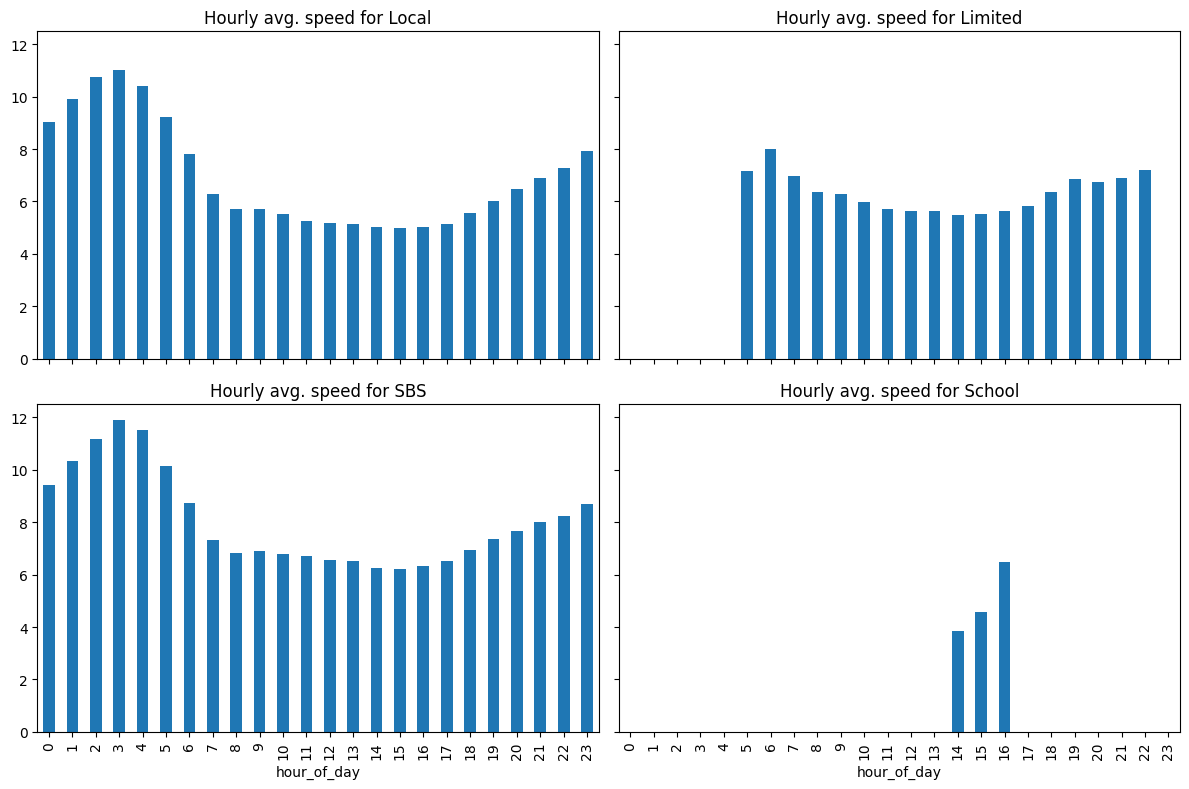

In [37]:
figs, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
options = list(segment_speed_df["route_type"].unique())
hours = list(range(24))

for i, ax in enumerate(axes.flatten()):
    if i < len(options):
        condition = options[i]
        subset = segment_speed_df[segment_speed_df["route_type"] == condition]
        subset = subset.groupby(["hour_of_day"])[["weight_travel_time", "weight_distance"]].sum().reindex(hours)
        subset["avg_speed"] = subset["weight_distance"] / subset["weight_travel_time"]
        subset["avg_speed"].plot(kind="bar", ax=ax)
        ax.set_title(f"Hourly avg. speed for {condition}")
    else:
        ax.set_visible(False)
        continue

plt.tight_layout()

## Average speed by hour of day and weekday

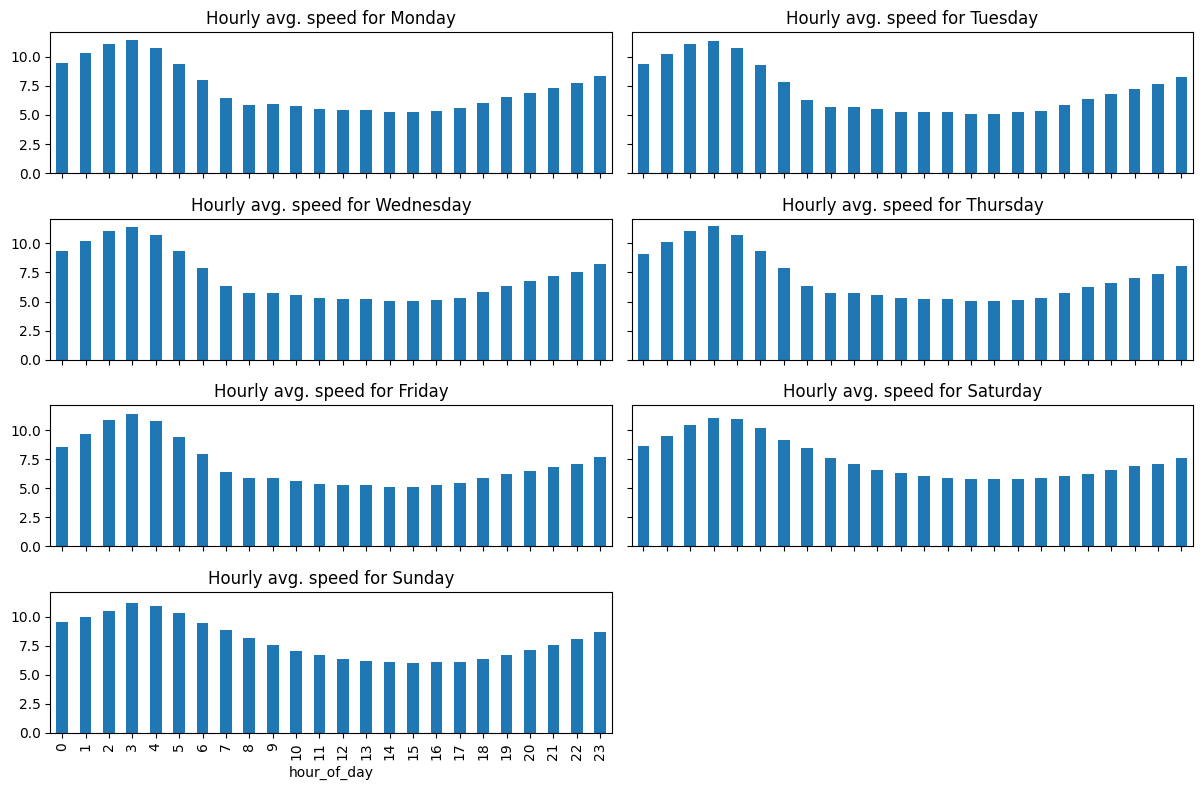

In [38]:
figs, axes = plt.subplots(4, 2, figsize=(12, 8), sharex=True, sharey=True)
weekday_options = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
hours = list(range(24))

for i, ax in enumerate(axes.flatten()):
    if i < len(weekday_options):
        condition = weekday_options[i]
        subset = segment_speed_df[segment_speed_df["day_of_week"] == condition]
        subset = subset.groupby(["hour_of_day"])[["weight_travel_time", "weight_distance"]].sum().reindex(hours)
        subset["avg_speed"] = subset["weight_distance"] / subset["weight_travel_time"]
        subset["avg_speed"].plot(kind="bar", ax=ax)
        ax.set_title(f"Hourly avg. speed for {condition}")
    else:
        ax.set_visible(False)

plt.tight_layout()

## Average speed comparison between 2023, 2024 and 2025

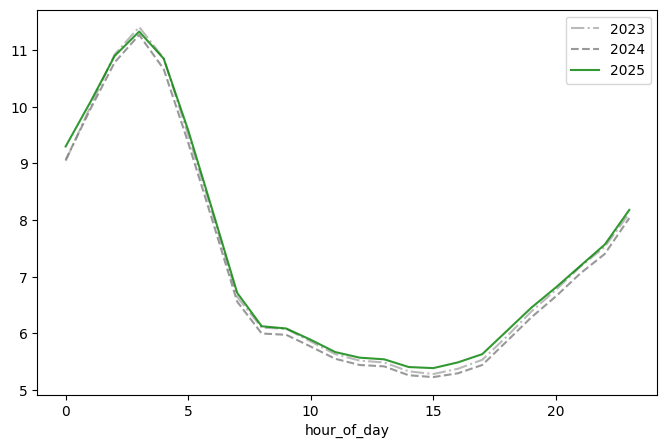

In [39]:
figs, axes = plt.subplots(figsize=(8, 5), sharex=True, sharey=True)
comparison_years = [2023, 2024, 2025]
comparison_colors = ["darkgrey", "grey", "g"]
linestyles = ['-.', '--', '-']
hours = list(range(24))

for idx, year in enumerate(comparison_years):
    subset = segment_speed_df[segment_speed_df["year"] == year]
    subset = subset.groupby(["hour_of_day"])[["weight_travel_time", "weight_distance"]].sum().reindex(hours)
    subset["avg_speed"] = subset["weight_distance"] / subset["weight_travel_time"]
    subset["avg_speed"].plot(kind="line", alpha=0.8, color=comparison_colors[idx], label=year, linestyle = linestyles[idx])
    plt.legend()

## Looking at change in average speed per bus per year vs. 2023

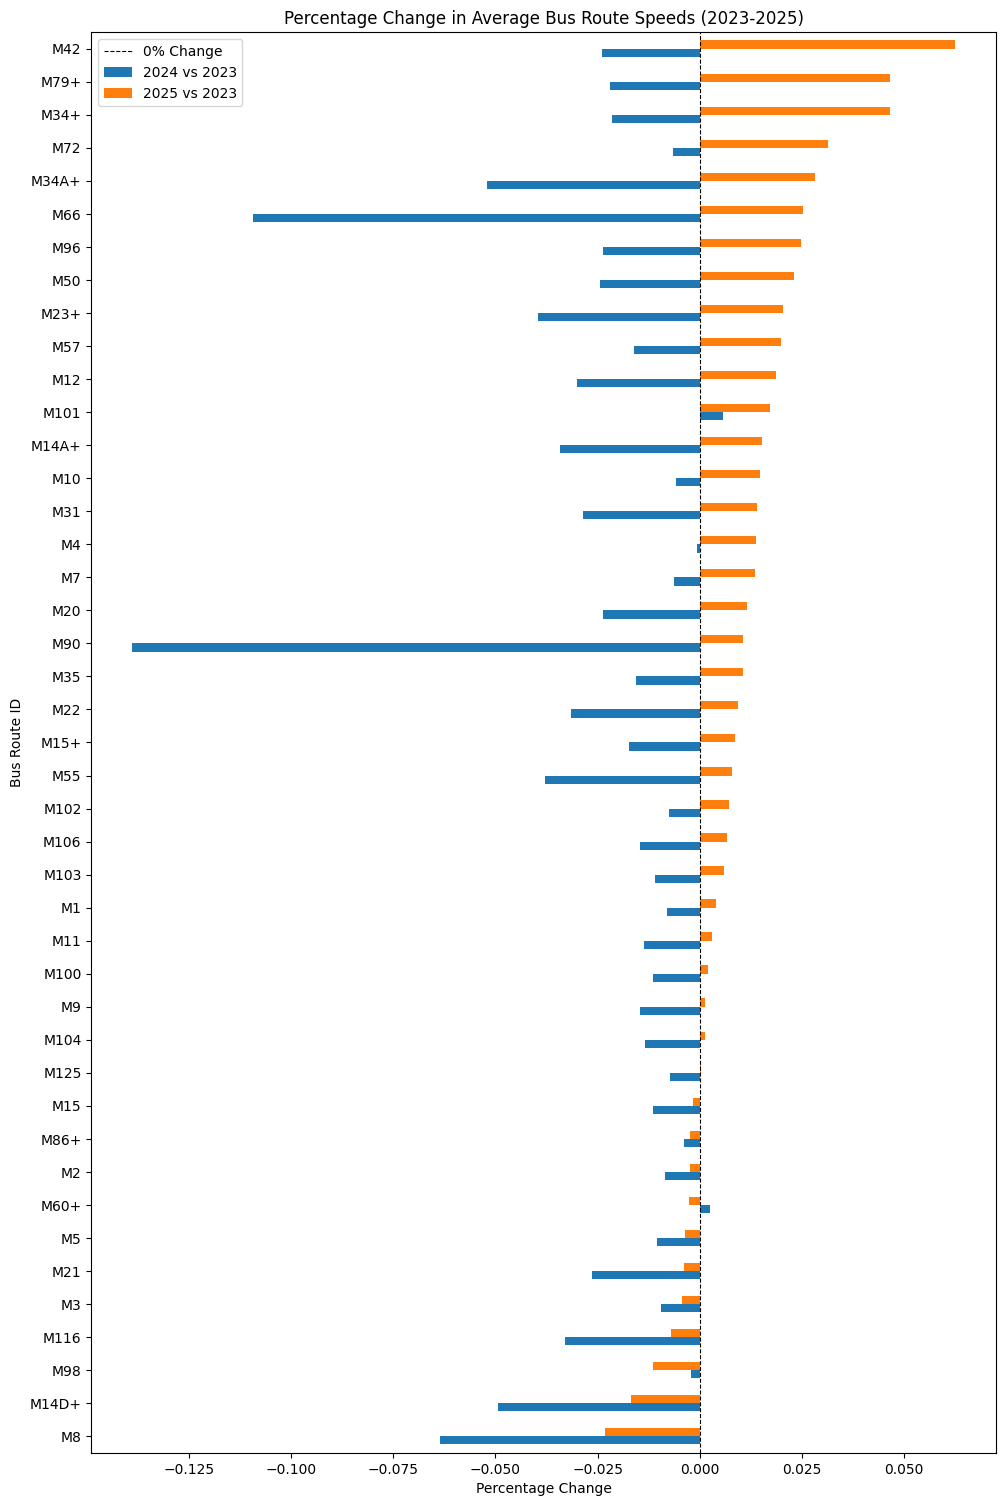

In [40]:
bus_speed = segment_speed_df.groupby(["year", "route_id"])[["weight_travel_time", "weight_distance"]].sum().unstack(level=0)
bus_speed[2023] = bus_speed[("weight_distance", 2023)] / bus_speed[("weight_travel_time", 2023)]
bus_speed[2024] = bus_speed[("weight_distance", 2024)] / bus_speed[("weight_travel_time", 2024)]
bus_speed[2025] = bus_speed[("weight_distance", 2025)] / bus_speed[("weight_travel_time", 2025)]

bus_speed["25_perc"] = (bus_speed[2025] - bus_speed[2023]) / bus_speed[2023].fillna(-np.inf)
bus_speed["24_perc"] = (bus_speed[2024] - bus_speed[2023]) / bus_speed[2023].fillna(-np.inf)

bus_speed["25_faster"] = (bus_speed[2025] - bus_speed[2023]) / bus_speed[2023].fillna(-np.inf)
bus_speed = bus_speed.sort_values(by=["25_faster"])

order = bus_speed.index.tolist()
bus_speed.loc[order, ["24_perc", "25_perc"]].plot(kind="barh", figsize=(10, 15), legend=True)
plt.title("Percentage Change in Average Bus Route Speeds (2023-2025)")
plt.xlabel("Percentage Change")
plt.ylabel("Bus Route ID")
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.legend(["0% Change", "2024 vs 2023", "2025 vs 2023"])
plt.tight_layout(pad=0.5)
plt.show()

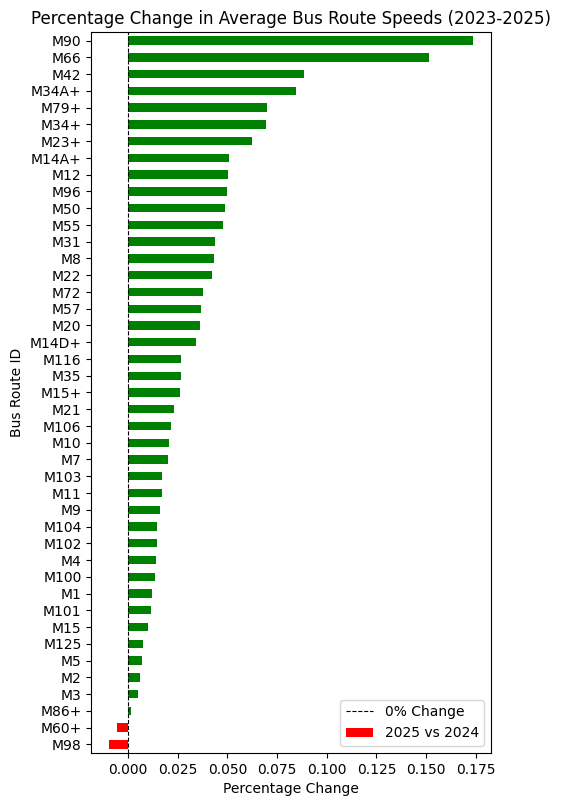

In [41]:
bus_speed["25_perc_24"] = (bus_speed[2025] - bus_speed[2024]) / bus_speed[2024].fillna(-np.inf)
bus_speed = bus_speed.sort_values(by= ["25_perc_24"])
colors_speed = np.where(bus_speed["25_perc_24"] >= 0, 'g', 'r')

# Plotting
order = bus_speed.index.tolist()
bus_speed["25_perc_24"].plot(kind="barh", figsize=(5,8), color=colors_speed)
plt.title("Percentage Change in Average Bus Route Speeds (2023-2025)")
plt.xlabel("Percentage Change")
plt.ylabel("Bus Route ID")
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend(["0% Change", "2025 vs 2024"])
plt.tight_layout(pad= 0.5)
plt.show()

## Looking at average speed per bus

Comparing average bus speeds from bus speeds and bus segment speeds datasets. Numbers are relatively close to each other. Do not know reason for small differences yet.

> Needs to be further investigated

In [42]:
test_df_2 = segment_speed_df[segment_speed_df["year"] == 2025].groupby(["route_id", "weekend"])[["weight_travel_time", "weight_distance"]].sum()
test_df_2["avg_speed"] = test_df_2["weight_distance"] / test_df_2["weight_travel_time"]
test_df_2.reset_index(inplace=True)
test_df_2["weekend"] = test_df_2["weekend"] + 1
test_df_2.rename(columns={"weekend": "day_type"}, inplace=True)
round(test_df_2, 2)

,route_id,day_type,weight_travel_time,weight_distance,avg_speed
0,M1,1,50938.93,296752.36,5.83
1,M1,2,11340.51,82370.11,7.26
2,M10,1,24619.13,147888.95,6.01
3,M10,2,8787.09,57161.97,6.51
4,M100,1,41044.01,250248.02,6.10
...,...,...,...,...,...
80,M90,1,19.40,162.53,8.38
81,M90,2,551.84,3961.93,7.18
82,M96,1,26036.72,141055.94,5.42
83,M96,2,5168.31,31101.31,6.02


In [43]:
test_df_3 = bus_speed_df[bus_speed_df["year"] == 2025].groupby(["year", "route_id", "day_type"])[["total_operating_time", "total_mileage"]].sum()
test_df_3["avg_speed"] = test_df_3["total_mileage"] / test_df_3["total_operating_time"]
round(test_df_3, 2)

total_operating_time  total_mileage  avg_speed
year route_id day_type                                                
2025 M1       1                     48046.86      279558.00       5.82
              2                     10423.16       76346.95       7.32
     M10      1                     23770.99      142229.86       5.98
              2                      8772.67       57294.78       6.53
     M100     1                     39245.12      239559.99       6.10
...                                      ...            ...        ...
     M9       2                      4849.55       32057.46       6.61
     M96      1                     25568.36      138271.74       5.41
              2                      5310.73       32116.02       6.05
     M98      1                      6959.36       61310.22       8.81
              2                        27.29         300.96      11.03

[84 rows x 3 columns]

Total averages for 2025 are very close to each other

In [44]:
results = np.sum(bus_speed_df[bus_speed_df["year"] == 2025][["total_operating_time", "total_mileage"]], axis = 0)
results["total_mileage"] / results["total_operating_time"]

np.float64(6.284084536590154)

In [45]:
results_2 = np.sum(test_df_2[["weight_distance", "weight_travel_time"]], axis = 0)
results_2["weight_distance"] / results_2["weight_travel_time"]

np.float64(6.271683182743698)

Differences accross the years are also similar

In [46]:
test_df_2 = segment_speed_df.groupby(["year", "route_id", "weekend"])[["weight_travel_time", "weight_distance"]].sum().unstack(level=0)
# test_df_2["avg_speed"] = test_df_2["weight_distance"] / test_df_2["weight_travel_time"]
test_df_2["2025_avg_speed"] = test_df_2[("weight_distance", 2025)] / test_df_2[("weight_travel_time", 2025)]
test_df_2["2024_avg_speed"] = test_df_2[("weight_distance", 2024)] / test_df_2[("weight_travel_time", 2024)]
test_df_2["2023_avg_speed"] = test_df_2[("weight_distance", 2023)] / test_df_2[("weight_travel_time", 2023)]

test_df_2.reset_index(inplace=True)
test_df_2["weekend"] = test_df_2["weekend"] + 1
test_df_2.rename(columns={"weekend": "day_type"}, inplace=True)
test_df_2.drop(columns=["weight_travel_time", "weight_distance"], inplace=True)

round(test_df_2, 2)

/var/folders/_d/ljvnpndd76v52vr16dysc7lr0000gn/T/ipykernel_41007/2064559251.py:10: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  test_df_2.drop(columns=["weight_travel_time", "weight_distance"], inplace=True)


,route_id,day_type,2025_avg_speed,2024_avg_speed,2023_avg_speed
year,,,,,
0,M1,1,5.83,5.75,5.77
1,M1,2,7.26,7.23,7.35
2,M10,1,6.01,5.85,5.87
3,M10,2,6.51,6.49,6.57
4,M100,1,6.10,6.02,6.08
...,...,...,...,...,...
80,M90,1,8.38,NaN,7.47
81,M90,2,7.18,6.15,7.01
82,M96,1,5.42,5.14,5.26


In [47]:
test_df_3 = bus_speed_df.groupby(["year", "route_id", "day_type"])[["total_operating_time", "total_mileage"]].sum().unstack(level=0)
# test_df_3["avg_speed"] = test_df_3["total_mileage"] / test_df_3["total_operating_time"]
test_df_3["2025_avg_speed"] = test_df_3[("total_mileage", 2025)] / test_df_3[("total_operating_time", 2025)]
test_df_3["2024_avg_speed"] = test_df_3[("total_mileage", 2024)] / test_df_3[("total_operating_time", 2024)]
test_df_3["2023_avg_speed"] = test_df_3[("total_mileage", 2023)] / test_df_3[("total_operating_time", 2023)]
test_df_3.reset_index(inplace=True)
test_df_3.drop(columns = ["total_operating_time", "total_mileage"], inplace=True)

round(test_df_3, 2)

/var/folders/_d/ljvnpndd76v52vr16dysc7lr0000gn/T/ipykernel_41007/4250865057.py:7: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  test_df_3.drop(columns = ["total_operating_time", "total_mileage"], inplace=True)


,route_id,day_type,2025_avg_speed,2024_avg_speed,2023_avg_speed
year,,,,,
0,M1,1,5.82,5.75,5.76
1,M1,2,7.32,7.35,7.47
2,M10,1,5.98,5.88,5.86
3,M10,2,6.53,6.59,6.61
4,M100,1,6.10,6.08,6.11
...,...,...,...,...,...
79,M9,2,6.61,6.49,6.60
80,M96,1,5.41,5.22,5.26
81,M96,2,6.05,5.92,6.04


## Looking at buses in CBD only

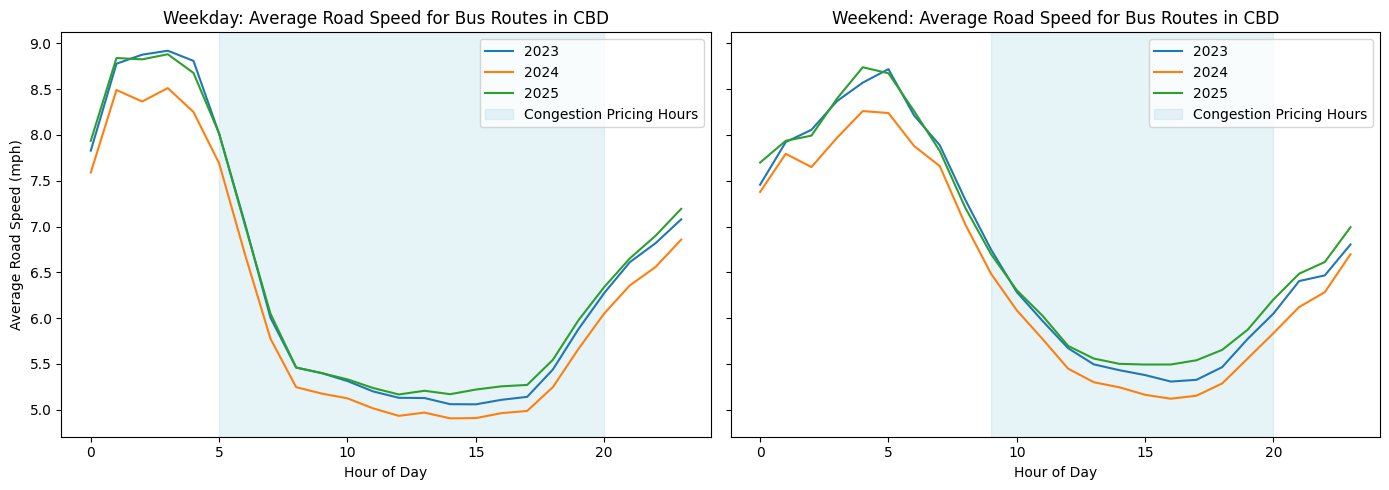

In [48]:
bus_routes_in_cbd = cbd_bus_routes_2025[cbd_bus_routes_2025["cbd_relation"] == "In CBD"].copy()
segment_speed_cbd = segment_speed_df[segment_speed_df["route_id"].isin(bus_routes_in_cbd["route_id"])].copy()
segment_speed_cbd["weekday"] = segment_speed_cbd["day_of_week"].apply(lambda x: 1 if x in ["Saturday", "Sunday"] else 0)

weekday_data = segment_speed_cbd[segment_speed_cbd["weekday"] == 0].groupby(["year", "hour_of_day"])[["weight_travel_time", "weight_distance"]].sum()
weekday_data["avg_speed"] = weekday_data["weight_distance"] / weekday_data["weight_travel_time"]
average_speed_cbd_weekday = weekday_data["avg_speed"].unstack(level=0)

weekend_data = segment_speed_cbd[segment_speed_cbd["weekday"] == 1].groupby(["year", "hour_of_day"])[["weight_travel_time", "weight_distance"]].sum()
weekend_data["avg_speed"] = weekend_data["weight_distance"] / weekend_data["weight_travel_time"]
average_speed_cbd_weekend = weekend_data["avg_speed"].unstack(level=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

average_speed_cbd_weekday.reindex(hours).plot(kind="line", ax=axes[0])
axes[0].set_title("Weekday: Average Road Speed for Bus Routes in CBD")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Average Road Speed (mph)")
axes[0].axvspan(5, 20, color="lightblue", alpha=0.3, label="Congestion Pricing Hours")
axes[0].legend(loc="upper right")

average_speed_cbd_weekend.reindex(hours).plot(kind="line", ax=axes[1])
axes[1].set_title("Weekend: Average Road Speed for Bus Routes in CBD")
axes[1].set_xlabel("Hour of Day")
axes[1].axvspan(9, 20, color="lightblue", alpha=0.3, label="Congestion Pricing Hours")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

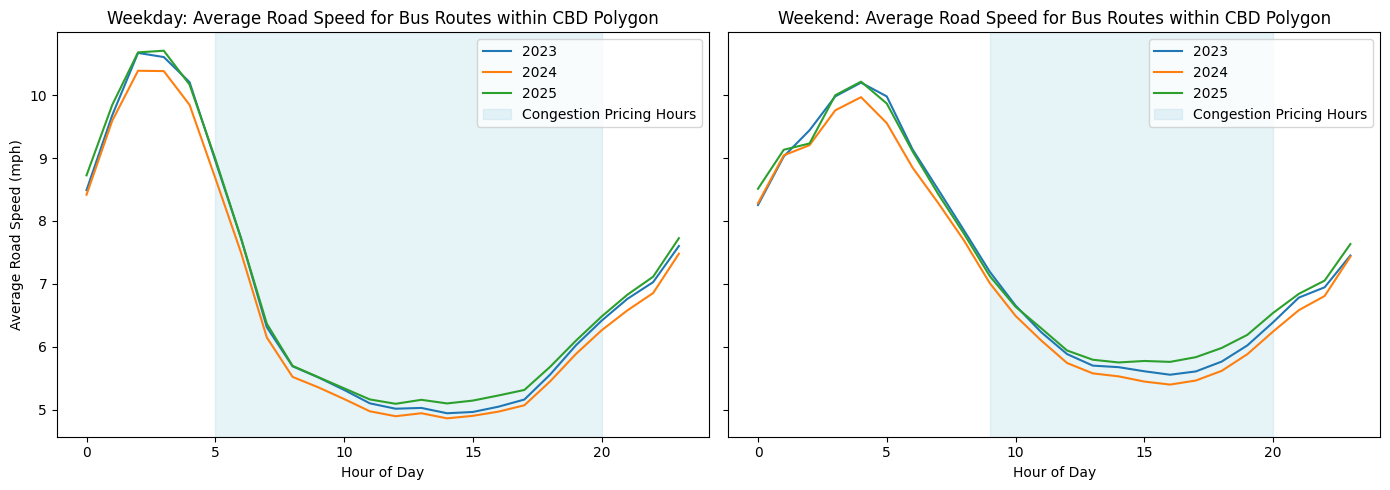

In [49]:
cbd_polygon = cbd_geojson_area_2024.geometry.union_all()
segment_speed_gdf = gpd.GeoDataFrame(
    segment_speed_df,
    geometry=gpd.points_from_xy(segment_speed_df["timepoint_stop_longitude"], segment_speed_df["timepoint_stop_latitude"]),
    crs="EPSG:4326",
 )
segment_speed_cbd_geom = segment_speed_gdf[segment_speed_gdf.within(cbd_polygon)]

segment_speed_cbd_weekend = segment_speed_cbd_geom[segment_speed_cbd_geom["day_of_week"].isin(["Saturday", "Sunday"])]
segment_speed_cbd_weekday = segment_speed_cbd_geom[~segment_speed_cbd_geom["day_of_week"].isin(["Saturday", "Sunday"])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

weekday_cbd_data = segment_speed_cbd_weekday.groupby(["year", "hour_of_day"])[["weight_travel_time", "weight_distance"]].sum()
weekday_cbd_data["avg_speed"] = weekday_cbd_data["weight_distance"] / weekday_cbd_data["weight_travel_time"]

weekend_cbd_data = segment_speed_cbd_weekend.groupby(["year", "hour_of_day"])[["weight_travel_time", "weight_distance"]].sum()
weekend_cbd_data["avg_speed"] = weekend_cbd_data["weight_distance"] / weekend_cbd_data["weight_travel_time"]
avg_speed_cbd_weekday = weekday_cbd_data["avg_speed"].unstack(level=0)
avg_speed_cbd_weekend = weekend_cbd_data["avg_speed"].unstack(level=0)

avg_speed_cbd_weekday.reindex(hours).plot(kind="line", ax=axes[0])
axes[0].set_title("Weekday: Average Road Speed for Bus Routes within CBD Polygon")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Average Road Speed (mph)")
axes[0].axvspan(5, 20, color="lightblue", alpha=0.3, label="Congestion Pricing Hours")
axes[0].legend(loc="upper right")

avg_speed_cbd_weekend.reindex(hours).plot(kind="line", ax=axes[1])
axes[1].set_title("Weekend: Average Road Speed for Bus Routes within CBD Polygon")
axes[1].set_xlabel("Hour of Day")
axes[1].axvspan(9, 20, color="lightblue", alpha=0.3, label="Congestion Pricing Hours")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## Looking at Vehicles entering Manhattan

This assumes, that vehicles only enter through the following tunnels and bridges:

`Henry Hudson Bridge`, `Hugh L. Carey Tunnel`, `Queens Midtown Tunnel`, `Robert F. Kennedy Bridge Bronx`, `Robert F. Kennedy Bridge Manhattan`

It also assumes, that all vehicles go to Manhattan even if they had a chance to go elsewhere.



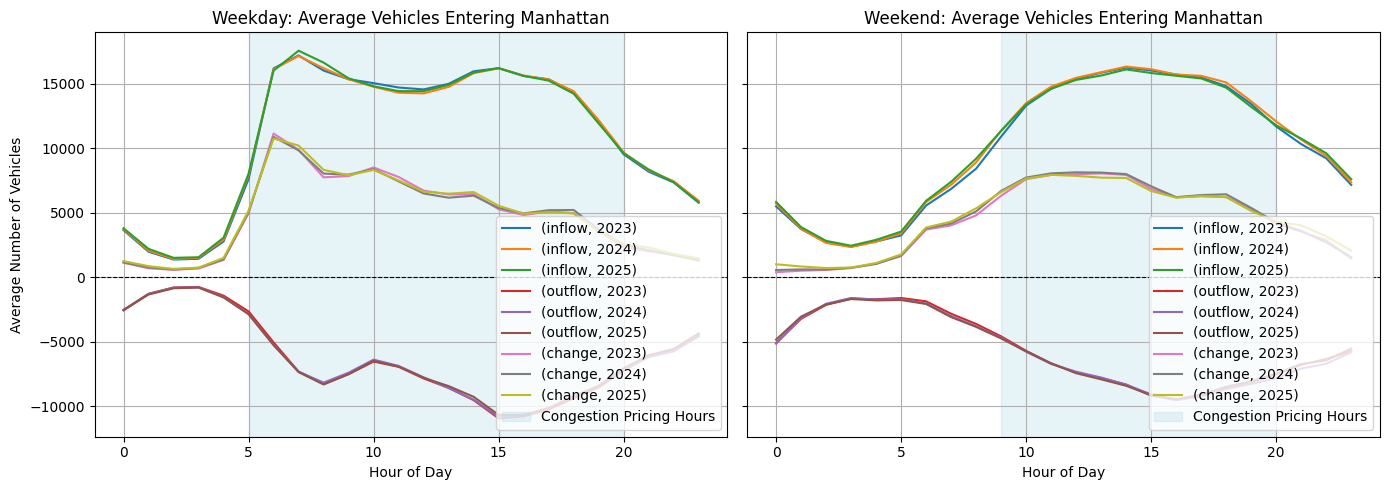

In [50]:
grouped_vehicles_entering = vehicles_entering_manhattan.groupby(["Year", "Month", "Day", "Weekend", "Hour"])[["inflow", "outflow", "change"]].sum().reset_index()

vehicles_entering_manhattan_weekend = grouped_vehicles_entering[grouped_vehicles_entering["Weekend"] == 1]
vehicles_entering_manhattan_weekday = grouped_vehicles_entering[grouped_vehicles_entering["Weekend"] == 0]


# Plotting average vehicles entering Manhattan
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- Weekday ---
weekday_avg = vehicles_entering_manhattan_weekday.groupby(["Year", "Hour"])[["inflow", "outflow", "change"]].mean().unstack(level=0)
weekday_avg.plot(ax=axes[0])
axes[0].axvspan(5, 20, color="lightblue", alpha=0.3, label="Congestion Pricing Hours")
axes[0].set_ylabel("Average Number of Vehicles")
axes[0].set_xlabel("Hour of Day")
axes[0].set_title("Weekday: Average Vehicles Entering Manhattan")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].legend(loc="lower right")
axes[0].grid(visible = True)

# --- Weekend ---
weekend_avg = vehicles_entering_manhattan_weekend.groupby(["Year", "Hour"])[["inflow", "outflow", "change"]].mean().unstack(level=0)
weekend_avg.plot(ax=axes[1])
axes[1].axvspan(9, 20, color="lightblue", alpha=0.3, label="Congestion Pricing Hours")
axes[1].set_ylabel("Average Number of Vehicles")
axes[1].set_xlabel("Hour of Day")
axes[1].set_title("Weekend: Average Vehicles Entering Manhattan")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].legend(loc="lower right")
axes[1].grid(visible = True)

plt.tight_layout()
plt.show()

## Looking at number of passengers

KeyError: 'Year'

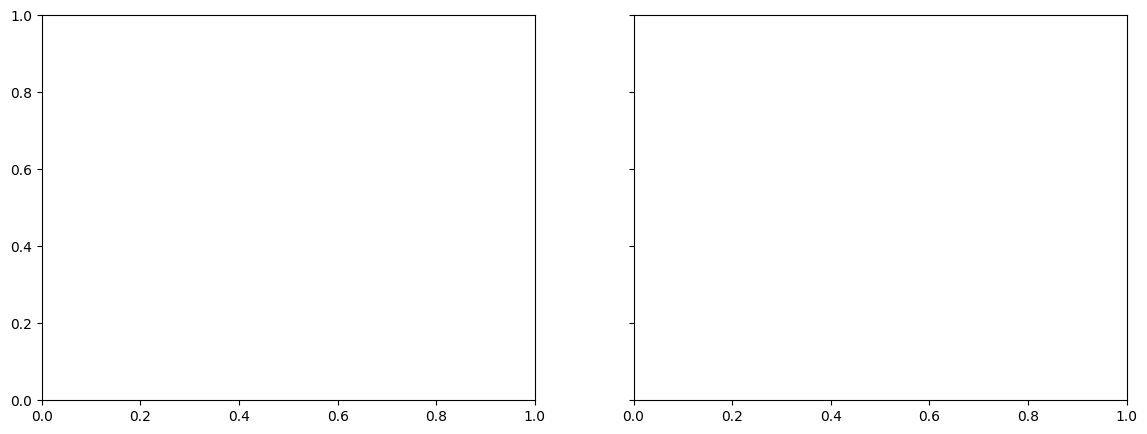

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# plot weekday
ridership_data_weekday.groupby(["Year", "Hour"])["total_ridership"].mean().unstack(level=0).plot(kind="line", ax=axes[0])
axes[0].set_title("Weekday: Average Hourly Ridership in Manhattan Bus Routes")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Average Ridership")
axes[0].axvspan(5, 20, color="lightblue", alpha=0.3, label="Cong. Pricing Hours")
axes[0].legend(loc="upper right")

# plot weekend
ridership_data_weekend.groupby(["Year", "Hour"])["total_ridership"].mean().unstack(level=0).plot(kind="line", ax=axes[1])
axes[1].set_title("Weekend: Average Hourly Ridership in Manhattan Bus Routes")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Average Ridership")
axes[1].axvspan(9, 20, color="lightblue", alpha=0.3, label="Congestion Pricing Hours")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## Vehicles entering CBD

### Vehicles entering per month

<Axes: xlabel='Year,Month'>

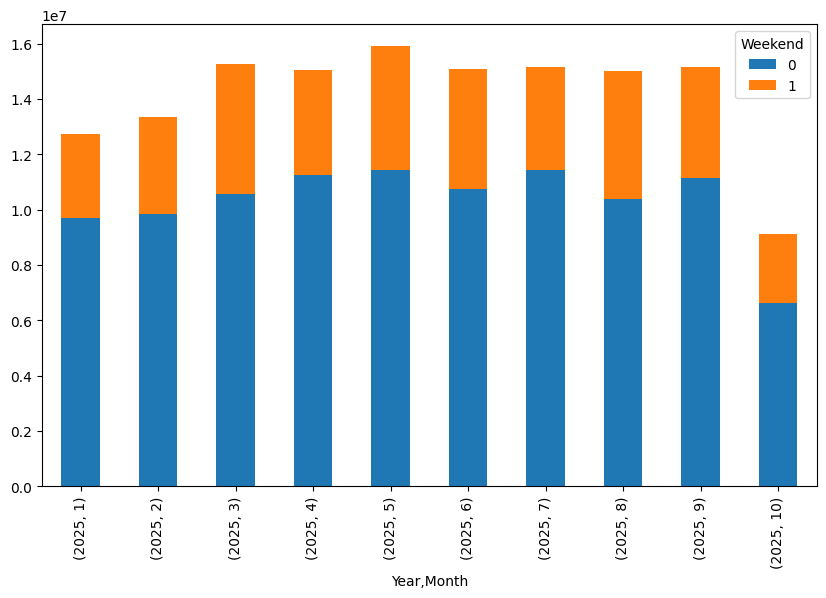

In [ ]:
vehicles_entering_cbd.groupby(["Year", "Month", "Weekend"])["sum_crz_entries"].sum().unstack(level=2).plot(kind="bar", figsize=(10, 6), stacked=True)

### Vehicles entering CBD on average by hour of day

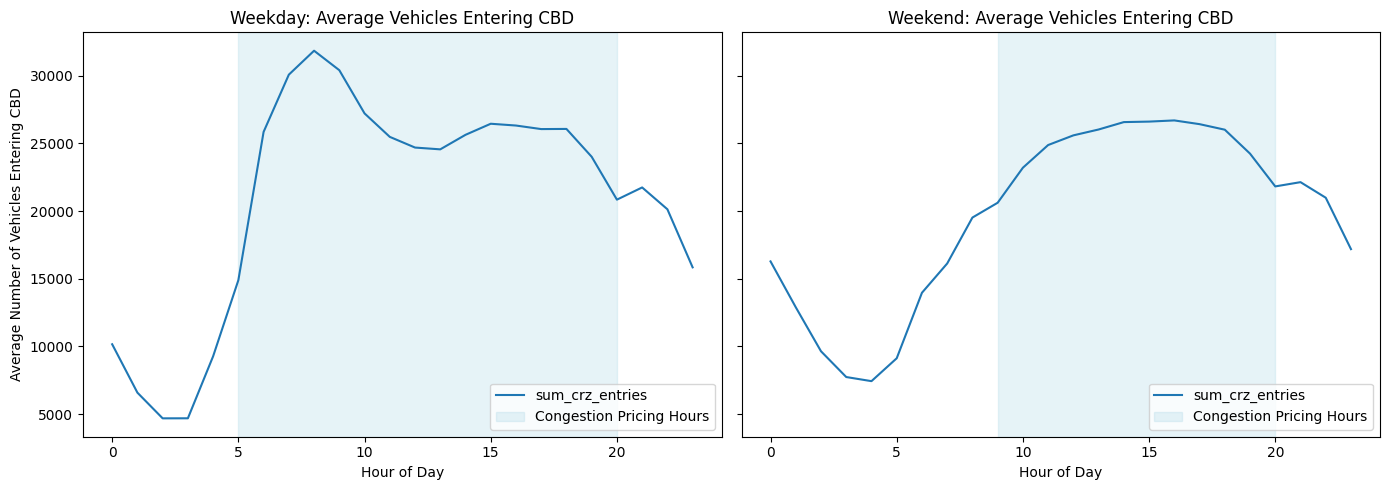

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

vehicles_entering_cbd_weekday.groupby("Hour")["sum_crz_entries"].mean().plot(kind="line", ax=axes[0])
axes[0].axvspan(5, 20, color="lightblue", alpha=0.3, label="Congestion Pricing Hours")
axes[0].set_ylabel("Average Number of Vehicles Entering CBD")
axes[0].set_xlabel("Hour of Day")
axes[0].set_title("Weekday: Average Vehicles Entering CBD")
axes[0].legend(loc="lower right")

vehicles_entering_cbd_weekend.groupby("Hour")["sum_crz_entries"].mean().plot(kind="line", ax=axes[1])
axes[1].axvspan(9, 20, color="lightblue", alpha=0.3, label="Congestion Pricing Hours")
axes[1].set_ylabel("Average Number of Vehicles Entering CBD")
axes[1].set_xlabel("Hour of Day")
axes[1].set_title("Weekend: Average Vehicles Entering CBD")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## Processing data for putting it on a map

### Interpolation Function

The `interpolate_missing_bus_stops()` function processes bus speed data to fill in missing stop segments.

**What it does:**
1. Identifies gaps in stop sequences (e.g., stop 5 → stop 8, missing 6 and 7)
2. Uses stop reference data to interpolate the missing stops
3. Fills in coordinates and metadata for interpolated stops
4. Inherits speed data from parent segment
5. Returns complete dataset with no gaps

In [ ]:
def interpolate_missing_bus_stops(speed_data, stop_data, month_filter=None, save_to_csv=False, output_filename="extended_list.csv"):
    """
    Interpolate missing bus stop segments between timepoints.

    Parameters
    ----------
    speed_data : pd.DataFrame
        DataFrame containing bus speed data with columns:
        ['year', 'month', 'day_of_week', 'hour_of_day', 'route_id', 'direction_id',
         'stop_order', 'timepoint_stop_id', 'timepoint_stop_name',
         'timepoint_stop_latitude', 'timepoint_stop_longitude',
         'next_timepoint_stop_id', 'next_timepoint_stop_name',
         'next_timepoint_stop_latitude', 'next_timepoint_stop_longitude',
         'road_distance', 'average_travel_time', 'average_road_speed']
    stop_data : pd.DataFrame
        DataFrame containing stop reference data with columns:
        ['route_id_new', 'stop_order_new', 'direction_id', 'stop_code',
         'stop_id', 'stop_name', 'latitude', 'longitude']
    month_filter : int, optional
        Filter data to specific month (1-12). If None, processes all months.
    save_to_csv : bool, default False
        Whether to save the result to a CSV file.
    output_filename : str, default "extended_list.csv"
        Name of the output CSV file if save_to_csv is True.
    """

    subset = speed_data.loc[:, [
        "year", "month", "day_of_week", "hour_of_day", "route_id", "direction_id",
        "stop_order", "timepoint_stop_id", "timepoint_stop_name",
        "timepoint_stop_latitude", "timepoint_stop_longitude",
        "next_timepoint_stop_id", "next_timepoint_stop_name",
        "next_timepoint_stop_latitude", "next_timepoint_stop_longitude",
        "road_distance", "average_travel_time", "average_road_speed"
    ]].copy()

    subset = subset.sort_values([
        "year", "month", "day_of_week", "hour_of_day", "route_id", "direction_id", "stop_order"
    ])
    subset["key"] = subset.loc[:, ["route_id", "direction_id"]].astype(str).agg("-".join, axis=1)

    if month_filter is not None:
        subset = subset[subset["month"] == month_filter]

    stops_subset = stop_data[["route_id_new", "stop_order_new", "direction_id", "stop_code"]].copy()
    stops_subset["key"] = stops_subset.loc[:, ["route_id_new", "direction_id"]].astype(str).agg("-".join, axis=1)

    merged_data = subset.merge(
        stops_subset,
        left_on=["key", "next_timepoint_stop_id"],
        right_on=["key", "stop_code"],
        how="left",
        suffixes=["", "_next_stop"]
    )

    merged_data.drop(["route_id_new", "direction_id_next_stop", "stop_code"], axis=1, inplace=True)
    merged_data.rename(columns={"stop_order_new": "next_stop_order"}, inplace=True)

    merged_data["missing_segments"] = merged_data.apply(
        lambda x: list(range(int(x["stop_order"]), int(x["next_stop_order"]) + 1))
        if pd.notna(x["next_stop_order"]) and x["next_stop_order"] - x["stop_order"] > 1
        else None,
        axis=1
    )

    original_rows = merged_data[merged_data["missing_segments"].isna()].copy()
    rows_to_expand = merged_data[merged_data["missing_segments"].notna()].copy()

    expanded_segments = rows_to_expand.explode("missing_segments")
    expanded_segments["target_stop_order"] = expanded_segments["missing_segments"].astype(int)
    expanded_segments["next_stop_order"] = expanded_segments["missing_segments"].astype(int) + 1

    stop_data_for_merge = stop_data[[
        "route_id_new", "direction_id", "stop_order", "stop_id", "stop_name", "latitude", "longitude"
    ]].copy()
    stop_data_for_merge["stop_order"] = stop_data_for_merge["stop_order"].astype(int)

    merged_expanded = expanded_segments.merge(
        stop_data_for_merge,
        left_on=["route_id", "direction_id", "target_stop_order"],
        right_on=["route_id_new", "direction_id", "stop_order"],
        how="left",
        suffixes=["", "_target"]
    )

    merged_expanded = merged_expanded.merge(
        stop_data_for_merge,
        left_on=["route_id", "direction_id", "next_stop_order"],
        right_on=["route_id_new", "direction_id", "stop_order"],
        how="left",
        suffixes=["", "_next"]
    )

    expanded_segments = expanded_segments.drop(["next_stop_order", "missing_segments"], axis=1)
    original_rows = original_rows.drop(["next_stop_order", "missing_segments"], axis=1)

    interpolated_rows = merged_expanded[[
        "year", "month", "day_of_week", "hour_of_day", "route_id",
        "direction_id", "target_stop_order",
        "stop_id", "stop_name", "latitude", "longitude",
        "stop_id_next", "stop_name_next",
        "latitude_next", "longitude_next", "average_road_speed",
        "key", "stop_order_next"
    ]].rename(columns={
        "target_stop_order": "stop_order",
        "stop_id": "timepoint_stop_id",
        "stop_name": "timepoint_stop_name",
        "latitude": "timepoint_stop_latitude",
        "longitude": "timepoint_stop_longitude",
        "stop_id_next": "next_timepoint_stop_id",
        "stop_name_next": "next_timepoint_stop_name",
        "latitude_next": "next_timepoint_stop_latitude",
        "longitude_next": "next_timepoint_stop_longitude",
        "stop_order_next": "next_stop_order"
    })

    interpolated_rows["road_distance"] = None
    interpolated_rows["average_travel_time"] = None

    original_rows["next_stop_order"] = original_rows["stop_order"] + 1
    original_rows_keep = original_rows[~original_rows["next_stop_order"].isna()].drop_duplicates()

    result_df = pd.concat([original_rows_keep, interpolated_rows], axis=0)
    result_df = result_df.dropna(subset=[
        "next_timepoint_stop_latitude",
        "timepoint_stop_latitude",
        "next_timepoint_stop_longitude",
        "timepoint_stop_longitude"
    ])

    if save_to_csv:
        result_df.to_csv(output_filename, index=False)

    return result_df

### Using function to process data

In [ ]:
stop_data

,route_short_name,route_long_name,route_id,direction_id,direction_name,stop_id,stop_code,stop_name,stop_order,latitude,longitude
0,M34-SBS,East Side - Javits Center,MTA NYCT_M34+,0,SELECT BUS EAST SIDE FDR DR CROSSTOWN,MTA_405286,405286,W 34 ST/12 AV,0,40.756419,-74.003657
1,M34-SBS,East Side - Javits Center,MTA NYCT_M34+,0,SELECT BUS EAST SIDE FDR DR CROSSTOWN,MTA_405587,405587,W 34 ST/11 AV,1,40.755718,-74.001884
2,M34-SBS,East Side - Javits Center,MTA NYCT_M34+,0,SELECT BUS EAST SIDE FDR DR CROSSTOWN,MTA_403192,403192,W 34 ST/10 AV,2,40.754330,-73.998776
3,M34-SBS,East Side - Javits Center,MTA NYCT_M34+,0,SELECT BUS EAST SIDE FDR DR CROSSTOWN,MTA_401818,401818,W 34 ST/9 AV,3,40.753106,-73.995857
4,M34-SBS,East Side - Javits Center,MTA NYCT_M34+,0,SELECT BUS EAST SIDE FDR DR CROSSTOWN,MTA_401819,401819,W 34 ST/8 AV,4,40.751988,-73.993312
...,...,...,...,...,...,...,...,...,...,...,...
2801,M90,M Shuttle Bus - Metropolitan Av - Myrtle Av,MTA NYCT_M90,1,M TRAIN TO MYRTLE - BROADWAY,MTA_801098,801098,SENECA AV/PALMETTO ST,3,40.702761,-73.907528
2802,M90,M Shuttle Bus - Metropolitan Av - Myrtle Av,MTA NYCT_M90,1,M TRAIN TO MYRTLE - BROADWAY,MTA_504119,504119,GATES AV/WYCKOFF AV,4,40.700050,-73.911769
2803,M90,M Shuttle Bus - Metropolitan Av - Myrtle Av,MTA NYCT_M90,1,M TRAIN TO MYRTLE - BROADWAY,MTA_304420,304420,MYRTLE AV/KNICKERBOCKER AV,5,40.698871,-73.918265
2804,M90,M Shuttle Bus - Metropolitan Av - Myrtle Av,MTA NYCT_M90,1,M TRAIN TO MYRTLE - BROADWAY,MTA_304423,304423,MYRTLE AV/DE KALB AV,6,40.698157,-73.925089


In [ ]:
new_df = interpolate_missing_bus_stops(segment_speed_df, stop_data, month_filter=8)

/var/folders/_d/ljvnpndd76v52vr16dysc7lr0000gn/T/ipykernel_32629/3597518313.py:122: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_df = pd.concat([original_rows_keep, interpolated_rows], axis=0)


In [ ]:
visualization_data = segment_speed_df[((segment_speed_df["year"] == 2024) |
                             (segment_speed_df["year"] == 2025)) &
                             (segment_speed_df["month"] == 8) &
                             (segment_speed_df["hour_of_day"].isin([2, 8, 14, 20]))
                             ]

extended_df = interpolate_missing_bus_stops(
    speed_data=visualization_data,
    stop_data=stop_data,
    month_filter=None,
    save_to_csv=True,
    output_filename="visualization_24_25.csv"
)

extended_df.head()

/var/folders/_d/ljvnpndd76v52vr16dysc7lr0000gn/T/ipykernel_32629/3597518313.py:122: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_df = pd.concat([original_rows_keep, interpolated_rows], axis=0)


,year,month,day_of_week,hour_of_day,route_id,direction_id,stop_order,timepoint_stop_id,timepoint_stop_name,timepoint_stop_latitude,timepoint_stop_longitude,next_timepoint_stop_id,next_timepoint_stop_name,next_timepoint_stop_latitude,next_timepoint_stop_longitude,road_distance,average_travel_time,average_road_speed,key,next_stop_order
0,2024,8,Friday,2,M10,0,1,403846,8 AV/W 57 ST,40.766740,-73.982683,401245,CENTRAL PK W/W 66 ST,40.772641,-73.978424,0.493,2.433318,12.156231,M10-0,2.0
7,2024,8,Friday,2,M101,0,1,405154,ASTOR PL/COOPER SQ EAST,40.729574,-73.990040,403855,3 AV/E 23 ST,40.739218,-73.982771,0.771,3.187500,14.512941,M101-0,2.0
11,2024,8,Friday,2,M101,0,34,403777,3 AV / E 97 ST,40.785730,-73.948748,401946,3 AV/E 99 ST,40.787906,-73.947273,0.170,0.603324,16.906339,M101-0,35.0
13,2024,8,Friday,2,M101,0,44,402502,E 125 ST/3 AV,40.803935,-73.936221,402512,W 125 ST/AMSTERDAM AV,40.813537,-73.956365,1.239,9.072222,8.194246,M101-0,45.0
30,2024,8,Friday,2,M101,1,73,402854,3 AV/E 23 ST,40.738982,-73.983129,903148,3 AV/ASTOR PL,40.729113,-73.990259,0.777,5.073336,9.189220,M101-1,74.0


---
# Creating map

In [ ]:
from folium.plugins import MarkerCluster

def plot_bus_routes(data_df, year=None, month=None, weekday=None, hour=None, route_id=None, marker=None):
    """Plot NYC bus routes with color indicating average speed."""
    df = data_df.copy()
    if month is not None:
        df = df[df["month"] == month]
    if weekday is not None:
        df = df[df["day_of_week"] == weekday]
    if route_id is not None:
        df = df[df["route_id"] == route_id]
    if hour is not None:
        df = df[df["hour_of_day"] == hour]
    if year is not None:
        df = df[df["year"] == year]

    routes = sorted(df["route_id"].dropna().unique())
    cmap_routes = plt.get_cmap("Paired", len(routes))
    route_colors = {r: mcolors.to_hex(cmap_routes(i)) for i, r in enumerate(routes)}

    speeds = df["average_road_speed"].dropna()
    min_speed, max_speed = speeds.min(), speeds.max()
    norm = mcolors.Normalize(vmin=min_speed, vmax=max_speed)
    cmap_speed = plt.get_cmap("RdYlGn")

    folium_map = folium.Map(location=[40.7831, -73.9712], zoom_start=12, tiles="CartoDB positron")
    marker_cluster = MarkerCluster(name="Stops", disableClusteringAtZoom=10, maxClusterRadius=60).add_to(folium_map)

    for _, row in df.iterrows():
        speed = row["average_road_speed"]
        lat1 = row.get("timepoint_stop_latitude")
        lon1 = row.get("timepoint_stop_longitude")
        lat2 = row.get("next_timepoint_stop_latitude")
        lon2 = row.get("next_timepoint_stop_longitude")
        line_coords = [[lat1, lon1], [lat2, lon2]]
        color = mcolors.to_hex(cmap_speed(norm(speed)))
        route_color = route_colors.get(row["route_id"])
        stop_names = [row["timepoint_stop_name"], row["next_timepoint_stop_name"]]

        if marker:
            for idx in range(2):
                folium.CircleMarker(
                    location=line_coords[idx],
                    radius=7,
                    color=route_color,
                    fill_color=route_color,
                    fill=True,
                    popup=f"Route: {row['route_id']} \n Stop: {stop_names[idx]}",
                ).add_to(marker_cluster)

        folium.PolyLine(
            locations=line_coords,
            color=color,
            weight=3,
            opacity=0.8,
            popup=f"{row['route_id']} | {speed:.1f} mph"
        ).add_to(folium_map)

    return folium_map

m = plot_bus_routes(new_df, year=2025, weekday="Tuesday", hour=6, marker=False)
m

# Regression Analysis

## Merging datasets for regression

In [ ]:
merged_data_for_regression = segment_speed_df.merge(
    ridership_data,
    left_on=["year", "month", "day_of_week", "hour_of_day", "route_id"],
    right_on=["year", "month", "day_of_week", "hour", "bus_route"],
    how="left",
    suffixes=["_speed", "_ridership"]
)

In [ ]:
merged_data_for_regression.columns

Index(['year', 'month', 'timestamp', 'day_of_week', 'hour_of_day', 'route_id',
       'route_type', 'stop_order', 'timepoint_stop_id', 'timepoint_stop_name',
       'timepoint_stop_latitude', 'timepoint_stop_longitude',
       'next_timepoint_stop_id', 'next_timepoint_stop_name',
       'next_timepoint_stop_latitude', 'next_timepoint_stop_longitude',
       'road_distance', 'average_travel_time', 'average_road_speed',
       'bus_trip_count', 'direction_id', 'weight', 'weighted_avg_speed',
       'weight_travel_time', 'weekend_speed', 'weight_distance',
       'transit_timestamp', 'bus_route', 'total_ridership', 'day', 'hour',
       'weekend_ridership'],
      dtype='object')

In [ ]:
merged_data_for_regression.drop(columns=["timestamp", "weekend_ridership", "day", "hour", "bus_route", "transit_timestamp"], inplace = True)

: 

In [ ]:
segment_speed_df

,year,month,timestamp,day_of_week,hour_of_day,route_id,route_type,stop_order,timepoint_stop_id,timepoint_stop_name,...,road_distance,average_travel_time,average_road_speed,bus_trip_count,direction_id,weight,weighted_avg_speed,weight_travel_time,weekend,weight_distance
0,2025,3,2025 Mar 01 12:00:00 PM,Thursday,12,M11,Local,7,403447,W 135 ST/BROADWAY,...,0.441,4.593336,5.760523,20,1,8.820,50.807812,1.531112,0,8.820
1,2025,3,2025 Mar 01 03:00:00 PM,Thursday,15,M50,Local,12,402171,E 50 ST/5 AV,...,0.500,11.384724,2.635110,12,0,6.000,15.810659,2.276945,0,6.000
2,2025,3,2025 Mar 01 11:00:00 PM,Thursday,23,M11,Local,7,403447,W 135 ST/BROADWAY,...,0.441,2.541660,10.410519,2,1,0.882,9.182078,0.084722,0,0.882
3,2025,3,2025 Mar 01 01:00:00 PM,Thursday,13,M50,Local,12,402171,E 50 ST/5 AV,...,0.500,9.177780,3.268764,12,0,6.000,19.612586,1.835556,0,6.000
4,2025,3,2025 Mar 01 04:00:00 AM,Thursday,4,M50,Local,12,402171,E 50 ST/5 AV,...,0.500,3.995838,7.507818,4,0,2.000,15.015635,0.266389,0,2.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1615715,2024,11,2024-11-01T21:00:00.000,Thursday,21,M101,Local,73,402854,3 AV/E 23 ST,...,0.777,5.266662,8.851910,3,1,2.331,20.633802,0.263333,0,2.331
1615716,2024,5,2024-05-01T12:00:00.000,Sunday,12,M3,Local,51,400397,SAINT NICHOLAS AV/W 125 ST,...,2.315,19.099998,7.272253,4,0,9.260,67.341065,1.273333,1,9.260
1615717,2024,5,2024-05-01T00:00:00.000,Sunday,0,M101,Local,73,402854,3 AV/E 23 ST,...,0.777,5.725008,8.143224,4,1,3.108,25.309141,0.381667,1,3.108
1615718,2024,5,2024-05-01T06:00:00.000,Sunday,6,M101,Local,73,402854,3 AV/E 23 ST,...,0.777,5.150010,9.052410,2,1,1.554,14.067445,0.171667,1,1.554


In [ ]:
ridership_data

,transit_timestamp,bus_route,total_ridership,month,day,year,hour,weekend,day_of_week
0,2025-01-01,M1,36,1,1,2025,0,0,Wednesday
1,2025-01-01,M10,23,1,1,2025,0,0,Wednesday
2,2025-01-01,M100,15,1,1,2025,0,0,Wednesday
3,2025-01-01,M101,229,1,1,2025,0,0,Wednesday
4,2025-01-01,M102,102,1,1,2025,0,0,Wednesday
...,...,...,...,...,...,...,...,...,...
1113931,2024-06-22,M60+,28,6,22,2024,0,1,Saturday
1113932,2024-10-22,M1,1035,10,22,2024,0,0,Tuesday
1113933,2024-10-31,M35,0,10,31,2024,0,0,Thursday
1113934,2024-12-01,M55,0,12,1,2024,0,1,Sunday


In [ ]:
%pip install sklearn 


# Aggregate ridership data to match bus speed granularity: Year, Month, day_of_week, Hour
ridership_agg = ridership_data.groupby(['Year', 'Month', 'day_of_week', 'Hour']).agg({
    'total_ridership': 'mean',
    'Weekend': 'first'
}).reset_index()

# Aggregate vehicles entering Manhattan: Year, Month, day_of_week, Hour
manhattan_agg = vehicles_entering_manhattan.groupby(['Year', 'Month', 'day_of_week', 'Hour']).agg({
    'inflow': 'mean',
    'outflow': 'mean',
    'change': 'mean',
    'Weekend': 'first'
}).reset_index()

# Aggregate CRZ entries: Year, Month, day_of_week, Hour
crz_agg = vehicles_entering_cbd.groupby(['Year', 'Month', 'day_of_week', 'Hour']).agg({
    'sum_crz_entries': 'mean',
    'Weekend': 'first'
}).reset_index()

# CBD speeds: aggregate to Year, Month, day_of_week, Hour if possible, but it's monthly, so merge on Year, Month
cbd_speeds_agg = cbd_vehicle_speeds_2023_2025.groupby(['Year', 'Month']).agg({
    'Average Speed': 'mean'  # assuming column name
}).reset_index()

# CBD bus routes: add a flag for CBD routes
cbd_routes_flag = cbd_bus_routes_2025[['route_id', 'cbd_relation']].copy()
cbd_routes_flag['in_cbd'] = (cbd_routes_flag['cbd_relation'] == 'In CBD').astype(int)

# Start with segment_speed_df
combined_df = segment_speed_df.copy()

# Merge ridership
combined_df = combined_df.merge(ridership_agg, on=['year', 'month', 'day_of_week', 'hour_of_day'], how='left')

# Merge Manhattan crossings
combined_df = combined_df.merge(manhattan_agg, on=['year', 'month', 'day_of_week', 'hour_of_day'], how='left')

# Merge CRZ entries
combined_df = combined_df.merge(crz_agg, on=['year', 'month', 'day_of_week', 'hour_of_day'], how='left')

# Merge CBD speeds (on Year, Month)
combined_df = combined_df.merge(cbd_speeds_agg, left_on=['year', 'month'], right_on=['Year', 'Month'], how='left')
combined_df.drop(['Year', 'Month'], axis=1, inplace=True)

# Merge CBD route flag
combined_df = combined_df.merge(cbd_routes_flag[['route_id', 'in_cbd']], on='route_id', how='left')

# Fill NaNs with 0 or mean where appropriate
combined_df.fillna({
    'total_ridership': 0,
    'inflow': 0,
    'outflow': 0,
    'change': 0,
    'sum_crz_entries': 0,
    'Average Speed': combined_df['Average Speed'].mean(),
    'in_cbd': 0
}, inplace=True)

# Prepare features for regression
features = ['year', 'month', 'hour_of_day', 'total_ridership', 'inflow', 'outflow', 'change', 'sum_crz_entries', 'Average Speed', 'in_cbd']
# Add dummies for categorical: day_of_week, route_type, direction_id
combined_df = pd.get_dummies(combined_df, columns=['day_of_week', 'route_type', 'direction_id'], drop_first=True)
features.extend([col for col in combined_df.columns if col.startswith(('day_of_week_', 'route_type_', 'direction_id_'))])

X = combined_df[features]
y = combined_df['average_road_speed']

# Handle any remaining NaNs
X = X.fillna(X.mean())

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Using statsmodels for detailed summary
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SK

ModuleNotFoundError: No module named 'sklearn'